### Variation of effective width as a function of loading fraction and material properties

Based on Kassapoglou [@Kassapoglou2013].

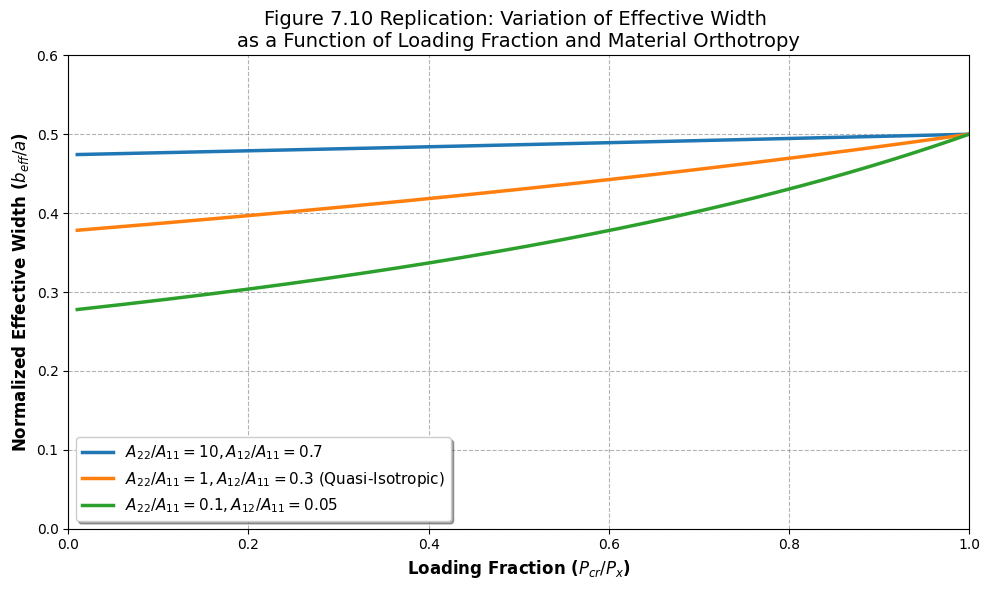

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the spectrum of load ratios (Pcr / Px) deep into the post-buckling regime
# The parameter ranges from 1.0 (the exact moment of bifurcation) down to 0.01
pcr_px = np.linspace(0.01, 1.0, 500)

# Define the orthotropy ratios representing different composite tailoring strategies
# Format structure: (A22/A11 ratio, A12/A11 ratio, Legend Label)
orthotropy_cases = [
    (10.0, 0.7, r'$A_{22}/A_{11}=10, A_{12}/A_{11}=0.7$'),
    (1.0, 0.3, r'$A_{22}/A_{11}=1, A_{12}/A_{11}=0.3$ (Quasi-Isotropic)'),
    (0.1, 0.05, r'$A_{22}/A_{11}=0.1, A_{12}/A_{11}=0.05$')
]

plt.figure(figsize=(10, 6))

# Iterate through the defined material cases to calculate and plot the effective width fraction
for a22_a11, a12_a11, label in orthotropy_cases:
    # Deconstruct the non-linear effective width equation for computational clarity
    # Term 1 accounts for the ratio of transverse to longitudinal stiffness: A11 / (A11 + 3*A22)
    # This mathematically equates to the simplified form: 1 / (1 + 3*(A22/A11))
    term1 = 1.0 / (1.0 + 3.0 * a22_a11)
    
    # Term 2 accounts for the multi-axial Poisson's effect coupling: (1 + A12/A11)
    term2 = 1.0 + a12_a11
    
    # Term 3 dynamically tracks the structural penetration into the post-buckling regime
    term3 = 1.0 - pcr_px
    
    # Synthesize the complete denominator of the effective width formula
    denominator = 2.0 + 2.0 * term2 * term3 * term1
    
    # Evaluate the final dimensionless effective width metric: b_eff / a
    beff_a = 1.0 / denominator
    
    # Plot the corresponding orthotropy curve
    plt.plot(pcr_px, beff_a, label=label, linewidth=2.5)

# Formatting the output chart to rigorously match aerospace engineering publication standards
plt.xlabel(r'Loading Fraction ($P_{cr} / P_x$)', fontsize=12, fontweight='bold')
plt.ylabel(r'Normalized Effective Width ($b_{eff} / a$)', fontsize=12, fontweight='bold')
plt.title('Figure 7.10 Replication: Variation of Effective Width \nas a Function of Loading Fraction and Material Orthotropy', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6, color='gray')
plt.legend(loc='best', fontsize=11, frameon=True, shadow=True)
plt.xlim(0, 1.0)
plt.ylim(0, 0.6)
plt.tight_layout()
plt.show()